# Colocalization Analysis — 16 Sample Dataset

**Outputs:**
- Dotplot: Colocalization of immune cell types with Endothelial cells (Stouffer's Weighted Z)
- Bar plot: AGT expression in SPP1+ and SPP1- Macrophages (NR vs R)

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy.spatial import cKDTree, Delaunay
import scipy.sparse as sp
import scipy.io as sio
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import pickle
import os
import gc
import warnings
warnings.filterwarnings("ignore")

OUTPUT_DIR = "colocalization_16"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/sample_level", exist_ok=True)


c:\Users\kfs1138\AppData\Local\miniconda3\envs\spatial\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
c:\Users\kfs1138\AppData\Local\miniconda3\envs\spatial\lib\site-packages\xarray_schema\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
c:\Users\kfs1138\AppData\Local\miniconda3\envs\spatial\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.w

In [2]:
# Data exported from Seurat using Matrix::writeMM to preserve all 18,934 genes.
# SeuratDisk::Convert() was not used as it silently drops non-HVGs.
#
# R export code:
#   library(Matrix)
#   writeMM(seurat_16sample[["RNA"]]$data, "normalized_counts.mtx")
#   write.csv(data.frame(gene = rownames(seurat_16sample[["RNA"]]$data)), "genes.csv", row.names = FALSE)
#   write.csv(data.frame(cell = colnames(seurat_16sample[["RNA"]]$data)), "barcodes.csv", row.names = FALSE)
#   write.csv(seurat_16sample@meta.data, "metadata.csv")

BUILD_FROM_MTX = False   # set True on first run to build from MTX files, False to reload h5ad

if BUILD_FROM_MTX:
    print("Building AnnData from MTX export...")
    X = sio.mmread("normalized_counts.mtx")
    X = sp.csr_matrix(X).T          # transpose to cells x genes
    genes    = pd.read_csv("genes.csv")
    barcodes = pd.read_csv("barcodes.csv")
    meta     = pd.read_csv("harmonized_seurat_metadata.csv", index_col=0)

    keep_mask = barcodes["cell"].isin(meta.index)
    keep_idx  = barcodes.index[keep_mask].values
    X_filtered       = X[keep_idx, :]
    barcodes_filtered = barcodes.loc[keep_mask].reset_index(drop=True)

    import anndata as ad
    adata16 = ad.AnnData(
        X   = X_filtered,
        obs = meta.loc[barcodes_filtered["cell"]],
        var = genes.set_index("gene"),
    )
    adata16.write_h5ad("seurat_16sample.h5ad")
    print("Saved: seurat_16sample.h5ad")

else:
    print("Loading from seurat_16sample.h5ad...")
    adata16 = sc.read_h5ad("seurat_16sample.h5ad")

print(f"Cells: {adata16.n_obs}, Genes: {adata16.n_vars}")


Loading from seurat_16sample.h5ad...
Cells: 803760, Genes: 18934


In [3]:
# Map samples to response groups
responders = [
    "AGS18-05009", "AGS19-13043", "WPS17-15624", "WPS19-04204",
    "AGS21-16129", "AGS15-6075",  "AGS19-04330", "WPS19-02322",
]
non_responders = [
    "AGS18-00413", "AGS19-14722", "AGS20-09037", "SVS21-12350",
    "AGS17-11762", "AGS22-00104", "AGS17-18785", "AGS20-03666",
]

response_map = {s: "R" for s in responders}
response_map.update({s: "NR" for s in non_responders})
adata16.obs["response"] = adata16.obs["sample"].map(response_map)

adata16.obsm["spatial"] = adata16.obs[["x_slide_mm", "y_slide_mm"]].values
adata16.obs["sample"]   = adata16.obs["sample"].astype("category")
adata16.obs["response"] = adata16.obs["response"].astype("category")

print(f"R cells:  {(adata16.obs['response'] == 'R').sum()}")
print(f"NR cells: {(adata16.obs['response'] == 'NR').sum()}")
print(f"Unmapped: {adata16.obs['response'].isna().sum()}")


R cells:  372004
NR cells: 431756
Unmapped: 0


In [5]:
IMMUNE_TYPES  = [
    "Macrophage_SPP1_Positive",
    "Macrophage_SPP1_Negative",
    "Lymphocytes",
    "Mast_cells",
    "Plasma",
]
ENDO_TYPES_ALL = ["Endothelial"]

sample_sizes = adata16.obs.groupby("sample").size()

def stouffer_z(z_scores, weights):
    w = np.array(weights)
    z = np.array(z_scores)
    mask = ~np.isnan(z)
    w, z = w[mask], z[mask]
    if len(z) == 0:
        return np.nan
    return np.sum(w * z) / np.sqrt(np.sum(w ** 2))

def run_sample_level_enrichment(adata, cluster_key, cell_types_of_interest,
                                 min_cells=5, n_perms=1000):
    samples = adata.obs["sample"].unique()
    records = []
    for sample in samples:
        adata_sub = adata[adata.obs["sample"] == sample].copy()
        adata_sub.obs[cluster_key] = adata_sub.obs[cluster_key].astype("category")
        ct_counts = adata_sub.obs[cluster_key].value_counts()
        missing = [ct for ct in cell_types_of_interest
                   if ct not in ct_counts.index or ct_counts[ct] < min_cells]
        if missing:
            print(f"  Skipping {sample} — insufficient cells: {missing}")
            continue
        sq.gr.spatial_neighbors(
            adata_sub, spatial_key="spatial",
            coord_type="generic", n_neighs=15,
        )
        sq.gr.nhood_enrichment(
            adata_sub, cluster_key=cluster_key,
            n_perms=n_perms, seed=42, show_progress_bar=False,
        )
        zscore_matrix = adata_sub.uns[f"{cluster_key}_nhood_enrichment"]["zscore"]
        labels   = adata_sub.obs[cluster_key].cat.categories.tolist()
        response = adata_sub.obs["response"].iloc[0]

        def get_z(ct1, ct2):
            if ct1 in labels and ct2 in labels:
                return zscore_matrix[labels.index(ct1), labels.index(ct2)]
            return np.nan

        record = {"sample": sample, "response": response}
        for immune in cell_types_of_interest:
            for endo in [ct for ct in cell_types_of_interest if "Endothelial" in ct]:
                record[f"{immune}_vs_{endo}"] = get_z(immune, endo)
        records.append(record)
    return pd.DataFrame(records)

def compute_stouffer_and_stats(df, score_cols, output_prefix):
    response_groups = sorted(df["response"].unique())
    g1, g2 = response_groups
    stouffer_rows = []
    stat_rows     = []
    for col in score_cols:
        if col not in df.columns:
            continue
        for resp in response_groups:
            sub = df[df["response"] == resp].dropna(subset=[col])
            weights = np.sqrt(sample_sizes.loc[sub["sample"]].values)
            z = stouffer_z(sub[col].values, weights)
            stouffer_rows.append({
                "comparison": col, "response": resp,
                "stouffer_z": z, "n_samples": len(sub),
                "median": sub[col].median(), "mean": sub[col].mean(),
            })
        s1 = df.loc[df["response"] == g1, col].dropna()
        s2 = df.loc[df["response"] == g2, col].dropna()
        if len(s1) > 1 and len(s2) > 1:
            u, p = stats.mannwhitneyu(s1, s2, alternative="two-sided")
            rbc  = 1 - (2 * u) / (len(s1) * len(s2))
        else:
            p, rbc = np.nan, np.nan
        stat_rows.append({
            "comparison": col,
            f"stouffer_z_{g1}": next((r["stouffer_z"] for r in stouffer_rows
                                      if r["comparison"]==col and r["response"]==g1), np.nan),
            f"stouffer_z_{g2}": next((r["stouffer_z"] for r in stouffer_rows
                                      if r["comparison"]==col and r["response"]==g2), np.nan),
            f"n_{g1}": len(s1), f"n_{g2}": len(s2),
            f"median_{g1}": s1.median() if len(s1) > 0 else np.nan,
            f"median_{g2}": s2.median() if len(s2) > 0 else np.nan,
            "MWU_p": p, "rank_biserial_r": rbc,
        })
    df_stouffer = pd.DataFrame(stouffer_rows)
    df_stats    = pd.DataFrame(stat_rows)
    valid = df_stats["MWU_p"].notna()
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(df_stats.loc[valid, "MWU_p"], method="fdr_bh")
        df_stats.loc[valid, "MWU_p_adj"] = p_adj
    df_stouffer.to_csv(f"{OUTPUT_DIR}/sample_level/{output_prefix}_stouffer.csv", index=False)
    df_stats.to_csv(f"{OUTPUT_DIR}/sample_level/{output_prefix}_stats.csv", index=False)
    return df_stouffer, df_stats

# Run enrichment — all Endothelial only
print("Running per-sample neighborhood enrichment...")
adata16.obs["cluster_for_cellchat"] = adata16.obs["cluster_for_cellchat"].astype("category")

df_sample_simple = run_sample_level_enrichment(
    adata16,
    cluster_key="cluster_for_cellchat",
    cell_types_of_interest=IMMUNE_TYPES + ENDO_TYPES_ALL,
)
df_sample_simple.to_csv(
    f"{OUTPUT_DIR}/sample_level/sample_enrichment_all_endo.csv", index=False
)

score_cols_simple = [f"{immune}_vs_Endothelial" for immune in IMMUNE_TYPES]
df_stouffer_simple, df_stats_simple = compute_stouffer_and_stats(
    df_sample_simple, score_cols_simple, "all_endo"
)

Running per-sample neighborhood enrichment...
  Skipping AGS18-00413 — insufficient cells: ['Macrophage_SPP1_Positive']


In [6]:
# Convert Stouffer Z scores to plot dataframe

def z_to_p(z):
    return 2 * (1 - norm.cdf(abs(z)))

plot_rows = []
for _, row in df_stouffer_simple.iterrows():
    z = row["stouffer_z"]
    if np.isnan(z):
        continue
    p = z_to_p(z)
    plot_rows.append({
        "comparison":  row["comparison"],
        "response":    row["response"],
        "stouffer_z":  z,
        "p":           p,
        "direction":   "enriched" if z > 0 else "depleted",
        "significant": p < 0.05,
    })

df_plot = pd.DataFrame(plot_rows)
df_plot["immune_type"] = df_plot["comparison"].str.replace(
    "_vs_Endothelial", "", regex=False
)

response_order = sorted(df_plot["response"].unique())
immune_order   = IMMUNE_TYPES[::-1]


## Colocalization with Endothelial Cells

Stouffer's weighted Z-score per response group. Red = enriched (Z > 1.96), blue = depleted (Z < −1.96), gray = not significant.

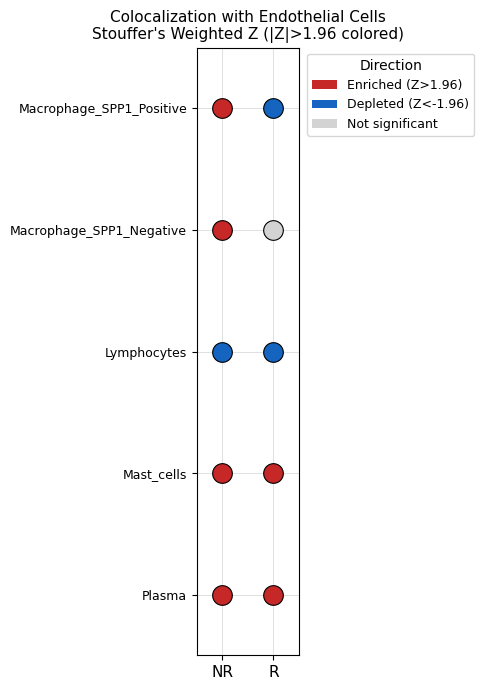

Saved: dotplot_all_endo.png/.pdf


In [7]:
fig, ax = plt.subplots(figsize=(5, 7))

DOT_SIZE = 200

for _, row in df_plot.iterrows():
    x = response_order.index(row["response"])
    y = immune_order.index(row["immune_type"]) \
        if row["immune_type"] in immune_order else None
    if y is None:
        continue

    # Color by Z threshold (1.96 = p~0.05 for standard normal)
    if row["stouffer_z"] > 1.96:
        color = "#C62828"
    elif row["stouffer_z"] < -1.96:
        color = "#1565C0"
    else:
        color = "lightgray"

    ax.scatter(x, y, s=DOT_SIZE, color=color,
               edgecolors="black", linewidths=0.8, zorder=2)

ax.set_xticks(range(len(response_order)))
ax.set_xticklabels(response_order, fontsize=11)
ax.set_yticks(range(len(immune_order)))
ax.set_yticklabels(immune_order, fontsize=9)
ax.set_xlim(-0.5, len(response_order) - 0.5)
ax.set_ylim(-0.5, len(immune_order) - 0.5)
ax.grid(True, color="lightgray", linewidth=0.5, zorder=0)
ax.set_title("Colocalization with Endothelial Cells\n"
             "Stouffer's Weighted Z (|Z|>1.96 colored)",
             fontsize=11)

color_handles = [
    mpatches.Patch(facecolor="#C62828", label="Enriched (Z>1.96)"),
    mpatches.Patch(facecolor="#1565C0", label="Depleted (Z<-1.96)"),
    mpatches.Patch(facecolor="lightgray", label="Not significant"),
]
ax.legend(handles=color_handles, loc="upper left",
          bbox_to_anchor=(1.02, 1), fontsize=9, title_fontsize=10,
          title="Direction")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/sample_level/dotplot_all_endo.png",
            dpi=150, bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/sample_level/dotplot_all_endo.pdf",
            bbox_inches="tight")
plt.show()
print("Saved: dotplot_all_endo.png/.pdf")

## AGT Expression in Macrophages

AGT expression in SPP1+ and SPP1- Macrophages, NR vs R. Normalized from raw counts. Bar plot shows per-sample mean ± SEM with Mann-Whitney p-values.

Genes found: ['AGT']
Response groups: g1=NR, g2=R


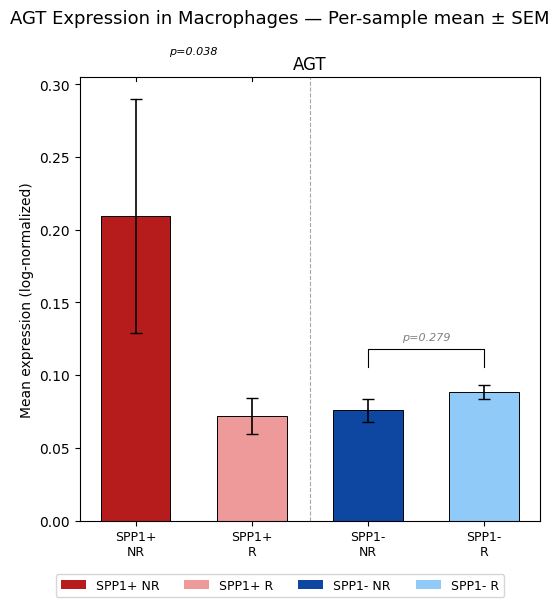

Saved: angiotensin_barplot_per_sample.png/.pdf


In [11]:
# AGT expression in SPP1+ and SPP1- Macrophages — NR vs R
# Per-sample mean ± SEM bar plot
# Normalized from raw counts: normalize_total(1e4) + log1p

import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np
import scipy.sparse as sp
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

GENES_OF_INTEREST = ["AGT"]
MAC_TYPES         = ["Macrophage_SPP1_Positive", "Macrophage_SPP1_Negative"]
OUTPUT_DIR        = "colocalization_16"

genes_found = [g for g in GENES_OF_INTEREST if g in adata16.var_names]
print(f"Genes found: {genes_found}")

# ── Normalize and build expr_df ───────────────────────────────────────────────
mac_mask  = adata16.obs["cluster_for_cellchat"].isin(MAC_TYPES)
adata_mac = adata16[mac_mask].copy()

sc.pp.normalize_total(adata_mac, target_sum=1e4)
sc.pp.log1p(adata_mac)

expr_df = pd.DataFrame({
    "cluster_for_cellchat": adata_mac.obs["cluster_for_cellchat"].values.astype(str),
    "sample":               adata_mac.obs["sample"].values.astype(str),
    "response":             adata_mac.obs["response"].values.astype(str),
})

for gene in genes_found:
    idx = list(adata_mac.var_names).index(gene)
    X   = adata_mac.X[:, idx]
    expr_df[gene] = (
        X.toarray().flatten() if sp.issparse(X) else np.array(X).flatten()
    )

response_groups = sorted(expr_df["response"].unique())
g1, g2 = response_groups
print(f"Response groups: g1={g1}, g2={g2}")

GROUP_ORDER = [
    f"SPP1 Positive {g1}",
    f"SPP1 Positive {g2}",
    f"SPP1 Negative {g1}",
    f"SPP1 Negative {g2}",
]
GROUP_PALETTE = {
    f"SPP1 Positive {g1}": "#B71C1C",
    f"SPP1 Positive {g2}": "#EF9A9A",
    f"SPP1 Negative {g1}": "#0D47A1",
    f"SPP1 Negative {g2}": "#90CAF9",
}

# ── Bar plot: per-sample mean ± SEM ──────────────────────────────────────────
n_genes = len(genes_found)
fig, axes = plt.subplots(1, n_genes, figsize=(5.5 * n_genes, 6), squeeze=False)
fig.suptitle("AGT Expression in Macrophages — Per-sample mean ± SEM", fontsize=13)

for col_i, gene in enumerate(genes_found):
    ax = axes[0][col_i]

    # Per-sample means
    sample_rows = []
    for (sample, response, mac_type), grp in expr_df.groupby(
        ["sample", "response", "cluster_for_cellchat"]
    ):
        mac_label = mac_type.replace("Macrophage_SPP1_", "SPP1 ")
        sample_rows.append({
            "group":  f"{mac_label} {response}",
            "sample": sample,
            "mean":   grp[gene].mean(),
        })
    sample_df = pd.DataFrame(sample_rows)

    summary = sample_df.groupby("group")["mean"].agg(
        mean_val="mean",
        sem_val=lambda x: x.std() / np.sqrt(len(x)),
        n="count",
    ).reset_index()
    summary["group"] = pd.Categorical(
        summary["group"], categories=GROUP_ORDER, ordered=True
    )
    summary = summary.sort_values("group").reset_index(drop=True)

    colors = [GROUP_PALETTE[g] for g in summary["group"]]
    x      = np.arange(len(summary))

    ax.bar(x, summary["mean_val"], color=colors,
           edgecolor="black", linewidth=0.7, width=0.6)
    ax.errorbar(x, summary["mean_val"], yerr=summary["sem_val"],
                fmt="none", color="black", capsize=4, linewidth=1.2, zorder=3)

    ax.set_ylim(bottom=0)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"SPP1+\n{g1}", f"SPP1+\n{g2}", f"SPP1-\n{g1}", f"SPP1-\n{g2}"],
        fontsize=9
    )
    ax.set_xlabel("")
    ax.set_ylabel("Mean expression (log-normalized)" if col_i == 0 else "")
    ax.set_title(gene, fontsize=12)
    ax.axvline(1.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)

    # P-value brackets from per-sample MWU
    for mac_i, mac_type in enumerate([
        "Macrophage_SPP1_Positive",
        "Macrophage_SPP1_Negative",
    ]):
        mac_label = mac_type.replace("Macrophage_SPP1_", "SPP1 ")
        s_nr = sample_df.loc[sample_df["group"] == f"{mac_label} {g1}", "mean"]
        s_r  = sample_df.loc[sample_df["group"] == f"{mac_label} {g2}", "mean"]
        if len(s_nr) > 1 and len(s_r) > 1:
            _, p  = stats.mannwhitneyu(s_nr, s_r, alternative="two-sided")
            pstr  = f"p={p:.3f}" if p >= 0.001 else f"p={p:.2e}"
            color = "black" if p < 0.05 else "gray"
        else:
            pstr, color = "NA", "gray"

        x1, x2 = mac_i * 2, mac_i * 2 + 1
        y_max = max(
            summary.iloc[x1]["mean_val"] + summary.iloc[x1]["sem_val"],
            summary.iloc[x2]["mean_val"] + summary.iloc[x2]["sem_val"],
        )
        h = ax.get_ylim()[1] * 0.04
        ax.plot([x1, x1, x2, x2],
                [y_max + h, y_max + 2*h, y_max + 2*h, y_max + h],
                color="black", linewidth=0.8)
        ax.text((x1 + x2) / 2, y_max + 2.5*h, pstr,
                ha="center", fontsize=8, style="italic", color=color)

legend_elements = [
    mpatches.Patch(facecolor="#B71C1C", label=f"SPP1+ {g1}"),
    mpatches.Patch(facecolor="#EF9A9A", label=f"SPP1+ {g2}"),
    mpatches.Patch(facecolor="#0D47A1", label=f"SPP1- {g1}"),
    mpatches.Patch(facecolor="#90CAF9", label=f"SPP1- {g2}"),
]
fig.legend(handles=legend_elements, loc="lower center",
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(f"{OUTPUT_DIR}/angiotensin_barplot_per_sample.png",
            dpi=150, bbox_inches="tight")
plt.savefig(f"{OUTPUT_DIR}/angiotensin_barplot_per_sample.pdf",
            bbox_inches="tight")
plt.show()
plt.close()
print("Saved: angiotensin_barplot_per_sample.png/.pdf")